In [1]:
# Example using a Maximum Likelihood Estimator to work out the power law distribution properties
# See Appendix of Hannah et al. 2011 for more details https://doi.org/10.1007/s11214-010-9705-4
# 
# For single power-law see example from 
# Crawford et al. 1970 https://doi.org/10.1086/150672 
# Wheatland et al. 2004 https://doi.org/10.1086/421261
# 
# For flattening power-law (i.e. double power-law) have approach of 
# Parnell & Jupp 2000 https://doi.org/10.1086/308271
# which works out where the break is for you !!!
# 
# 21-Sep-2026 IGH

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sunpy.io.special import read_genx
from astropy.time import Time

import warnings
warnings.simplefilter('ignore')

matplotlib.rcParams['font.size']=16

In [3]:
# load in the data
# Load in the sswidl genx make by rhessi_weeflares_results.ipynb
res=read_genx('wee_all_v2.genx')

# And extract out of the dictionary
# Thermal and Non-thermal energy in erg
eng_th=res["SAVEGEN0"]["ENG_TH"]
eng_nn=res["SAVEGEN0"]["ENG_NN_EC"]
# Events with "good" fits (th, nn, th+gs, nn+gs)
idgdth=res["SAVEGEN0"]["IDGDTH"]
idgdnn=res["SAVEGEN0"]["IDGDNN"]
idgsgdth=res["SAVEGEN0"]["IDGSGDTH"]
idgsgdnn=res["SAVEGEN0"]["IDGSGDNN"]

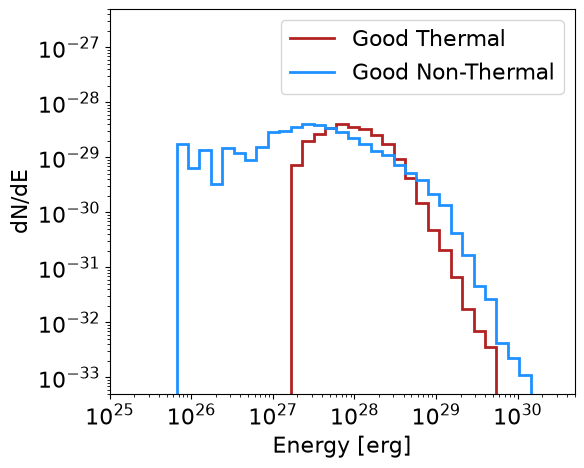

In [4]:
#  Plot the energy distriubtions
num, ebins=np.histogram(np.log10(eng_th[idgdth]),bins=50,range=[24,31])
numnn, ebins=np.histogram(np.log10(eng_nn[idgdnn]),bins=ebins)

de=[10**ebins[i+1]-10**ebins[i] for i in range(len(ebins)-1)]
fig,ax=plt.subplots(figsize=(6,5))
plt.stairs(num/de/(len(eng_th[idgdth])),10**ebins,color='firebrick',lw=2,label='Good Thermal')
plt.stairs(numnn/de/(len(eng_nn[idgdnn])),10**ebins,color='dodgerblue',lw=2,label='Good Non-Thermal')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Energy [erg]')
ax.set_ylabel('dN/dE')
ax.set_xlim([1e25,5e30])
ax.set_ylim([5e-34,5e-27])
ax.xaxis.set_major_locator(mticker.LogLocator(numticks=999))
ax.xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
plt.legend(loc=1)
plt.show()

In [5]:
def mle_powlaw(x, xmin=None, xmax=None):
    """Estimate a power-law index and its uncertainty using maximum
    likelihood, following Bai (1993) and Wheatland (2004) 
    https://doi.org/10.1086/421261

    Parameters
    ----------
    x : array-like
        Data values from which the power-law index is estimated.
    xmin : float, optional
        Lower limit of the range used for the maximum-likelihood fit.
        If None, the minimum valid data value is used.
    xmax : float, optional
        Upper limit of the range used for the maximum-likelihood fit.
        If None, the maximum valid data value is used.

    Notes
    -----
    The maximum-likelihood estimate assumes an untruncated continuous
    power law above xmin. xmax is used to select the data included in
    the fit and to set the plotted range; it does not enter the
    likelihood normalisation as an upper truncation.

    The returned PDF is calculated for the full valid data set, while
    the power-law index is estimated only from the specified
    xmin <= x <= xmax range.
    """

    x = np.asarray(x, dtype=float)
    good = np.isfinite(x) & (x != 0)
    if not np.any(good):
        raise ValueError("x must contain at least one finite, non-zero value")

    x_good = x[good]
    if xmin is None:
        xmin = x_good.min()
    if xmax is None:
        xmax = x_good.max()
    if xmin <= 0 or xmax < xmin:
        raise ValueError("mle_powlaw requires 0 < xmin <= xmax")

    # x_max here is really just used for plotting truncation
    selected = x_good[(x_good >= xmin) & (x_good <= xmax)]
    nn = selected.size
    if nn < 3:
        raise ValueError("at least three selected values are required")

    ci = selected / xmin
    log_total = np.sum(np.log(ci))
    if log_total <= 0:
        raise ValueError("selected values must include values above xmin")

    gam_est = nn / log_total + 1.0
    gam_err = (gam_est - 1.0) * nn / ((nn - 1.0) * np.sqrt(nn - 2.0))

    xs = np.sort(x_good)
    ngd = x_good.size
    rank = np.arange(ngd, dtype=float)
    pdf = ((gam_est - 1.0) / xmin) * (1.0 - (rank - 0.5) / ngd)

    x_fit = np.array([xmin / 1e2, xmax * 1e2])
    pdf_fit = ((gam_est - 1.0) / xmin) * (x_fit / xmin) ** (-gam_est)

    return {
        "gam_est": gam_est,
        "gam_err": gam_err,
        "x_fit": x_fit,
        "pdf_fit": pdf_fit,
        "xs": xs,
        "pdf": pdf,
    }

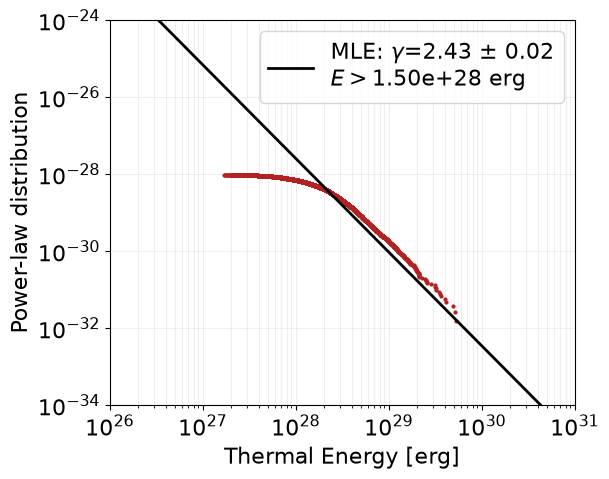

gamma = 2.4330 +/- 0.0199
E_min = 1.5e+28 erg, E_max = 5.324e+29 erg


In [6]:
# You need to manually specify the energy range to fit the power-law over
xmin_mle = 1.5e28
mle_result = mle_powlaw(eng_th[idgdth], xmin=xmin_mle, xmax=1e30)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(mle_result["xs"], mle_result["pdf"], ".", ms=4,
        color="firebrick")
ax.plot(mle_result["x_fit"], mle_result["pdf_fit"], "k-", lw=2,
        label=(rf"MLE: $\gamma$={mle_result['gam_est']:.2f} $\pm$ "
               f"{mle_result['gam_err']:.2f}\n"
               f"$E>${xmin_mle:.2e} erg"))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Thermal Energy [erg]")
ax.set_ylabel("Power-law distribution")
ax.grid(which="both", alpha=0.2)
ax.legend(loc="best")
ax.set_ylim(1e-34,1e-24)
ax.set_xlim(1e26,1e31)
plt.show()

print(f"gamma = {mle_result['gam_est']:.4f} +/- {mle_result['gam_err']:.4f}")
print(f"E_min = {xmin_mle:.4g} erg, E_max = {mle_result['xs'].max():.4g} erg")

In [7]:
def ml_plfit(engs,mnnrg = 1.0e24):
    """Estimate the parameters of a broken power-law energy
    distribution using the maximum-likelihood approach of
    Parnell & Jupp (2000) https://doi.org/10.1086/308271

    Parameters
    ----------
    engs : array-like
        Event energies.
    mnnrg : float, optional
        Energy scale used to normalise the energies before taking
        logarithms. Default is 1e24, appropriate for typical flare
        energies. This scaling does not affect the fitted power-law
        parameters.
    Notes
    -----
    The method estimates a break energy together with the power-law
    indices above and below the break. The distribution is allowed to
    flatten below the break, following the formulation of Parnell &
    Jupp (2000).

    The energies are normalised by mnnrg before the likelihood
    calculation to keep the logarithmic values numerically convenient.
    The choice of mnnrg does not affect the fitted indices or the
    physical break energy.

    The returned `gam` and `phi` parameters describe the slopes of the
    high- and low-energy branches, respectively, using the sign
    convention of the Parnell & Jupp formulation.
    """

    energies = np.asarray(engs, dtype=float)
    good = np.isfinite(energies) & (energies > 0.0)
    nrg = energies[good] / mnnrg
    if nrg.size < 3:
        raise ValueError("at least three finite, positive energies are required")

    slnrg = np.sort(np.log(nrg))
    nlnrg = slnrg.size
    sengs = np.exp(slnrg)

    # IDL ss(k) is the sum of the first k sorted log energies.
    ss = np.zeros(nlnrg + 1)
    ss[1:] = np.cumsum(slnrg)

    ll = np.zeros(nlnrg + 1)
    indices = np.arange(1, nlnrg)
    numerator = 1.0 - indices / nlnrg
    denominator = ss[nlnrg] / nlnrg - ss[indices] / indices
    ll[indices] = numerator / denominator

    rhat = np.argmax(ll)
    nuhat = slnrg[rhat]
    gdenum = ss[nlnrg] / nlnrg - ss[rhat] / rhat
    gammahat = 1.0 / gdenum
    betahat = rhat / nlnrg
    phihat = gammahat * (1.0 - betahat) / betahat
    kk = gammahat * phihat / (gammahat + phihat)

    nrg0 = np.exp(nuhat) * mnnrg
    gamma = -gammahat - 1.0
    phi = phihat - 1.0

    lower = np.flatnonzero(slnrg < nuhat)
    upper = np.flatnonzero(slnrg >= nuhat)
    if lower.size == 0 or upper.size == 0:
        raise ValueError("the fitted distribution must contain both branches")

    y1 = slnrg[lower]
    ff1 = (lower + 0.5) / rhat
    lff1 = np.log(ff1) - y1 + np.log(kk)
    xxl = np.exp(y1)
    lcpf = (xxl / np.exp(nuhat)) ** phihat

    y2 = slnrg[upper]
    ff2 = 1.0 - (upper - rhat + 0.5) / (nlnrg - rhat)
    lff2 = np.log(ff2) - y2 + np.log(kk)
    xxr = np.exp(y2)
    rcpf = (xxr / np.exp(nuhat)) ** (-gammahat)

    gammasq = gammahat**2 / (nlnrg * (1.0 - betahat))
    gammainterval = 1.96 * np.sqrt(gammasq)
    nusq = 2.0 * betahat / (nlnrg * gammahat**2 * (1.0 - betahat))
    nuinterval = 1.96 * np.sqrt(nusq)
    phisq = phihat**2 / (nlnrg * betahat)
    phiinterval = 1.96 * np.sqrt(phisq)

    c = gammahat * nuhat
    xfit2 = np.array([y2.min() - 2.0, y2.max() + 2.0])
    yfit2 = (-gammahat - 1.0) * xfit2 + c + np.log(kk)

    c = phihat * nuhat
    xfit1 = np.array([y1.min() - 2.0, y1.max() + 2.0])
    yfit1 = (phihat - 1.0) * xfit1 - c + np.log(kk)

    return {
        "engs": sengs * mnnrg,
        "dobs": np.concatenate((np.exp(lff1), np.exp(lff2))) / mnnrg,
        "xdobs": np.concatenate((np.exp(y1), np.exp(y2))) * mnnrg,
        "x1pobs": np.exp(xfit1) * mnnrg,
        "y1pobs": np.exp(yfit1) / mnnrg,
        "x2pobs": np.exp(xfit2) * mnnrg,
        "y2pobs": np.exp(yfit2) / mnnrg,
        "eb": nrg0,
        "gam": gamma,
        "egam": gammainterval,
        "phi": phi,
        "ephi": phiinterval,
        "rhat": rhat,
        "nl": nlnrg,
        "pbrk": lower.max(),
        "nuhat": nuhat,
        "nuinterval": nuinterval,
        "lcpf": lcpf,
        "rcpf": rcpf,
    }

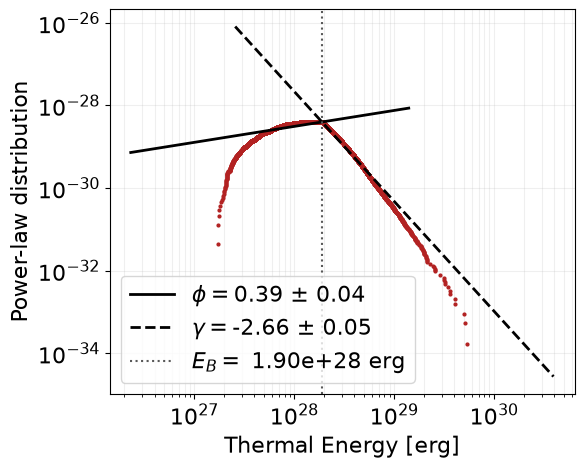

break energy = 1.895e+28 erg
gamma = -2.6617 +/- 0.0504
phi = 0.3864 +/- 0.0384


In [8]:
# The advantage of the Parnell & Jupp version is that you just give it all the data
# and it works out where the break is
plfit_result = ml_plfit(eng_th[idgdth])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(plfit_result["xdobs"], plfit_result["dobs"], ".",
        color="firebrick", ms=4)
ax.plot(plfit_result["x1pobs"], plfit_result["y1pobs"], "k-", lw=2,
        label=f"$\phi=${plfit_result['phi']:.2f} $\pm$ {plfit_result['ephi']:.2f}")
ax.plot(plfit_result["x2pobs"], plfit_result["y2pobs"], "k--", lw=2,
        label=rf"$\gamma=${plfit_result['gam']:.2f} $\pm$ {plfit_result['egam']:.2f}")
ax.axvline(plfit_result["eb"], color="0.35", ls=":", lw=1.5,
           label=f"$E_B =$ {plfit_result['eb']:.2e} erg")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Thermal Energy [erg]")
ax.set_ylabel("Power-law distribution")
ax.grid(which="both", alpha=0.2)
ax.legend(loc="best")
plt.show()

print(f"break energy = {plfit_result['eb']:.4g} erg")
print(f"gamma = {plfit_result['gam']:.4f} +/- {plfit_result['egam']:.4f}")
print(f"phi = {plfit_result['phi']:.4f} +/- {plfit_result['ephi']:.4f}")

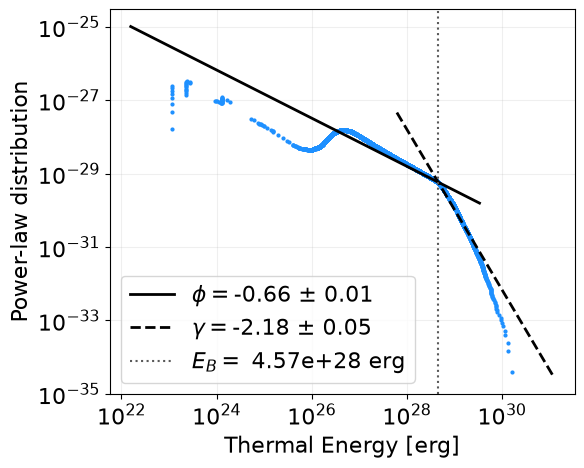

break energy = 4.566e+28 erg
gamma = -2.1847 +/- 0.0511
phi = -0.6561 +/- 0.0080


In [9]:
# Repeat for the non-thermal
plfit_result = ml_plfit(eng_nn[idgdth])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(plfit_result["xdobs"], plfit_result["dobs"], ".",
        color="dodgerblue", ms=4)
ax.plot(plfit_result["x1pobs"], plfit_result["y1pobs"], "k-", lw=2,
        label=f"$\phi=${plfit_result['phi']:.2f} $\pm$ {plfit_result['ephi']:.2f}")
ax.plot(plfit_result["x2pobs"], plfit_result["y2pobs"], "k--", lw=2,
        label=rf"$\gamma=${plfit_result['gam']:.2f} $\pm$ {plfit_result['egam']:.2f}")
ax.axvline(plfit_result["eb"], color="0.35", ls=":", lw=1.5,
           label=f"$E_B =$ {plfit_result['eb']:.2e} erg")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Thermal Energy [erg]")
ax.set_ylabel("Power-law distribution")
ax.grid(which="both", alpha=0.2)
ax.legend(loc="best")
plt.show()

print(f"break energy = {plfit_result['eb']:.4g} erg")
print(f"gamma = {plfit_result['gam']:.4f} +/- {plfit_result['egam']:.4f}")
print(f"phi = {plfit_result['phi']:.4f} +/- {plfit_result['ephi']:.4f}")